# SVI PARAMETRIZATION

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
import pandas as pd


In [2]:
T = 1/12

#Table (Source: Bloomberg, 16th March 2024)

EURUSD_K = np.array([1.0681, 1.0791, 1.0904, 1.1014, 1.1119])
EURUSD_vol = np.array([0.0554, 0.053115, 0.0516, 0.051435, 0.0523])

GBPUSD_K = np.array([1.2456, 1.2595, 1.2740, 1.2883, 1.3017])
GBPUSD_vol = np.array([0.06055, 0.058665, 0.0573, 0.057185, 0.05765])

EURGBP_K = np.array([0.84386, 0.84969, 0.85585, 0.86234, 0.86875])
EURGBP_vol = np.array([0.03809, 0.03725, 0.037225, 0.03825, 0.03986])

# Forward price (same date)
F0_EURUSD = 1.0903
F0_GBPUSD = 1.2738
F0_EURGBP =0.85590


In [3]:
#Log-moneyness  x =ln(K/F0)

EURUSD_x = np.log(EURUSD_K / F0_EURUSD)
GBPUSD_x = np.log(GBPUSD_K / F0_GBPUSD)
EURGBP_x = np.log(EURGBP_K / F0_EURGBP)

In [4]:
print("EURUSD:", EURUSD_x.min(), EURUSD_x.max())
print("GBPUSD:", GBPUSD_x.min(), GBPUSD_x.max())
print("EURGBP:", EURGBP_x.min(), EURGBP_x.max())

EURUSD: -0.02057151861668628 0.019617375996867605
GBPUSD: -0.022387217417476825 0.021666543535149352
EURGBP: -0.014166942827932145 0.01490184999143784


In [5]:
market_data = {
    "EURUSD": {"F0": F0_EURUSD, "K": EURUSD_K, "x": EURUSD_x, "vol": EURUSD_vol},
    "GBPUSD": {"F0": F0_GBPUSD, "K": GBPUSD_K, "x": GBPUSD_x, "vol": GBPUSD_vol},
    "EURGBP": {"F0": F0_EURGBP, "K": EURGBP_K, "x": EURGBP_x, "vol": EURGBP_vol},
}


In [6]:
# B-S Call F0=S0 (undiscounted forward call price) 
# This is later used for Breeden-Litzenberger (second derivative wrt to K)
def bs_call(F0, K, sigma, T):
    d1 = (np.log(F0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return F0 * norm.cdf(d1) - K * norm.cdf(d2)

In [7]:
# SVI fitting equation

def w_svi(x, a, b, sig, rho, m):
    return a + b * (rho*(x - m) + np.sqrt((x - m)**2 + sig**2))

# converting Gath 'w into implied vol equation

def Gath_impvol(x, a, b, sig, rho, m,T):
    return np.sqrt(w_svi(x, a, b, sig, rho, m) / T)

In [8]:
# Least Square Calibration with regularisation or penalty for the wing-bound (butterfly arbitrage) constraint

def LS_error(params, x, market_impvol, T, regularisation_const):   
    a,b,sig,rho,m = params
    impvol_fit = Gath_impvol(x, a, b, sig, rho, m,T)  # using this candidate (a,b,sigma,rho and m) compute what implied volatility the SVI formula would predict at each of the markets strikes via w_svi total variamce formula  converted to vol
    error = 1e3*np.sum((market_impvol - impvol_fit)**2)   # fit directly in implied-vol space (not option prices), keeps all 5 quotes on a comparable scale
    
    
    #Wing-bound (butterfly arbitrage) regularisation - not calendar arbitrage, which doesn't apply here (single maturity)
    penalty = 0.0
    if b*(1+abs(rho))>4/T:
        penalty+=regularisation_const*(b*(1+abs(rho))-4/T) #this the whole penalty

    return error +penalty

In [9]:
# Minimisation of LSE

def SVI_params(x, market_impvol, T, regularisation_const=1e6): #1e6 default: orders of magnitude bigger than the error term (~1-100), so any wing-bound violation always costs more than any fit-quality gain - see Obsidian TASK 1 note
    w0 = (market_impvol**2 * T).mean()

    bounds = [
        (0.0,    w0 * 3),
        (1e-8,   0.5),
        (1e-8,   0.5),
        (-0.999, 0.999),
        (-0.03, 0.03),
    ]

    res_g = differential_evolution(LS_error, bounds,    # differenctial-evolution is a global optimizer (it does not use gradients)
                                   args=(x, market_impvol, T, regularisation_const),
                                    polish=True)

    result = minimize(LS_error, res_g.x,
                      args=(x, market_impvol, T, regularisation_const),    #res_g.x = instead of straint from some arbitrary guess, its strats exactly from the best parameter set by DE
                      method='L-BFGS-B', bounds=bounds,     
                      options={'maxiter': 5000, 'ftol': 1e-15}) #(L-BFGS_B) a faster gradient-based local method  that squeezes out more precision than the DE alone would give
    return result.x


SVI Calibration Parameters:

               a         b       sig       rho         m       Wing
EURUSD  0.000174  0.002357  0.019752 -0.191958  0.002396 -47.997190
GBPUSD  0.000258  0.001314  0.011821 -0.473848  0.000132 -47.998064
EURGBP  0.000089  0.001832  0.014137  0.093022 -0.002134 -47.997998


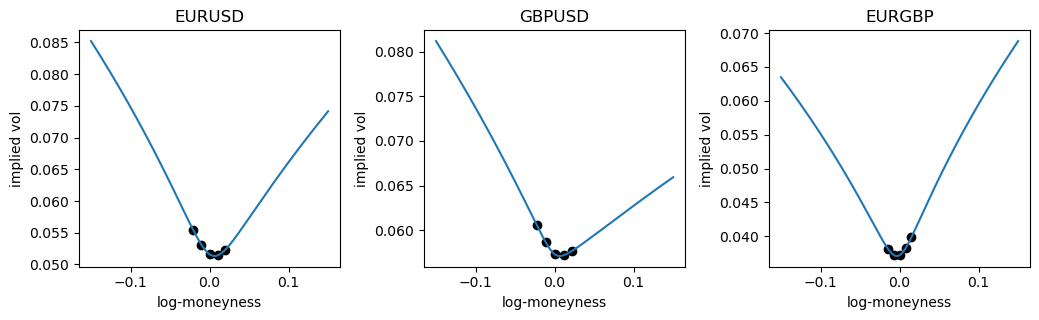

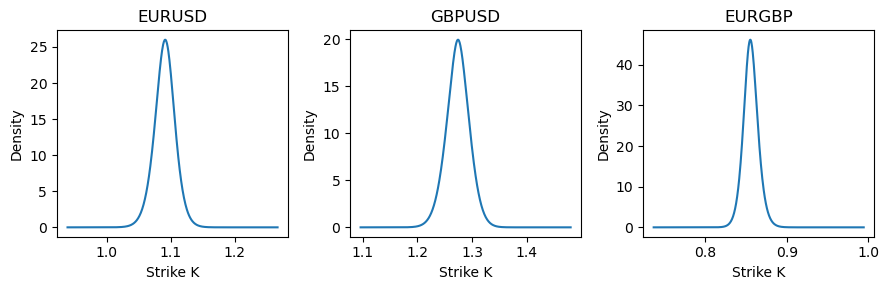

In [10]:
def w_svi(x, a, b, sig, rho, m):
    return a + b * (rho * (x - m) + np.sqrt((x - m)**2 + sig**2))


fig1, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
x_grid = np.linspace(-0.15, 0.15, 200)
svi_results = {}

for ax, (pair, data) in zip(axes, market_data.items()):
    x_mkt = data["x"]
    market_vol = data["vol"]
    a, b, sig, rho, m = SVI_params(x_mkt, market_vol, T)
    svi_results[pair] = {"a": a, "b": b, "sig": sig, "rho": rho, "m": m, "Wing" : (b*(1+abs(rho))-4/T)}

    w_grid = w_svi(x_grid, a, b, sig, rho, m)
    vol_grid = np.sqrt(w_grid / T)

    ax.scatter(x_mkt, market_vol, c="black")
    ax.plot(x_grid, vol_grid)
    ax.set_title(pair, fontsize=12)
    ax.set_xlabel("log-moneyness", fontsize=10)
    ax.set_ylabel("implied vol", fontsize=10)

svi_table = pd.DataFrame(svi_results).T
print("\nSVI Calibration Parameters:\n")
print(svi_table)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(9,3))
x_grid = np.linspace(-0.15, 0.15, 600)

for ax2, (pair, data) in zip(axes2, market_data.items()):
    F0 = data["F0"]
    a,b,sig,rho,m= svi_results[pair]["a"], svi_results[pair]["b"], svi_results[pair]["sig"], svi_results[pair]["rho"], svi_results[pair]["m"]

    K_grid = F0 * np.exp(x_grid)
    vol_grid = Gath_impvol(x_grid, a, b, sig, rho,m, T)
    calls = np.array([bs_call(F0,K,s,T) for K, s in zip(K_grid, vol_grid)])
    density = np.gradient(np.gradient(calls, K_grid), K_grid)    #Breeden-Lizenberg formula

    ax2.plot(K_grid, density)
    ax2.set_title(pair)
    ax2.set_xlabel("Strike K")
    ax2.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [11]:
# Making sure the densities are actually probability distributions
dx = K_grid[1]-K_grid[0]
prob = density*dx
prob = prob/prob.sum() # normalization(since numerical differentiation introduces small errors)

print(prob.sum())

0.9999999999999999


Therefore, density is integrating correctly, valid discrete probability measure.

Need to check densities are positive 

In [12]:
density = np.gradient(np.gradient(calls, K_grid),K_grid)
print(f"{pair}: minimum density = {density.min():.10e}")
print(f"{pair}: all non-negative = {np.all(density >= 0)}")


EURGBP: minimum density = -5.6229509937e-10
EURGBP: all non-negative = False


# SINKHORN ALGORITHM

Step 1: build a continuous, smooth density function for each pair (PCHIP interpolation of the Breeden-Litzenberger density, normalised directly in strike (K) space to avoid Jacobian mixups) - separate from the quadrature nodes used in Step 2

In [13]:
from scipy.interpolate import PchipInterpolator

def build_density_function(pair, lo, hi, n=4000):  #this n needs to be larget than the n=400 from before as the next steps differenciate twice and finite differences are noiser
    F0 = market_data[pair]["F0"]
    a, b, sig, rho, m = (svi_results[pair]["a"], svi_results[pair]["b"],
                         svi_results[pair]["sig"], svi_results[pair]["rho"], svi_results[pair]["m"])
    K_grid = np.linspace(lo, hi, n)
    x_grid = np.log(K_grid / F0)
    vol_grid = Gath_impvol(x_grid, a, b, sig, rho, m, T)
    calls = np.array([bs_call(F0, K, s, T) for K, s in zip(K_grid, vol_grid)])    #rebuilds the full call-price implied by the SVI smile
    density = np.gradient(np.gradient(calls, K_grid), K_grid)  
    density = np.clip(density, 0, None)   #double-differenciating introduces tiny negative noise near where the density is close to 0, so just remove the floating-point noise (np.clip)
    density = density / np.trapz(density, K_grid)      # forces the density to integrate to exactly 1 (after two numerical derivatives plus the clipping above the curve wont sum exactly 1 on its own   )
    moneyness_grid = K_grid / F0                       #it takes whatever raw raw strikes  and rescales them onto this shares, comparable footing
    density_moneyness = density * F0      #changing the x-axis isn't free, correction factor in order to strech or shrink the x-axis             # Y=K/F0, dK=F0*dY - constant Jacobian, no per-node mixup
    return PchipInterpolator(moneyness_grid, density_moneyness, extrapolate=False)  # takes these now correctly-rescaled points and turns them into actual callable function, so this basically  function in such a way that if you handle a moneyness value it hands you back a density. And the extrapolate = False means if you ever asked for a point outside the range it was built it returns a NaN
                                                                                    #the function returns a PchipInterpolator object rather than an array and muX_func, muY_func, muZ_func are those 3 objects. The density is held as something callabale at any point, not as a list fixed of values
muX_func = build_density_function("EURUSD", 0.7, 1.5)
muY_func = build_density_function("GBPUSD", 0.7, 1.5)
muZ_func = build_density_function("EURGBP", 0.5, 1.6)

Step 2: Gauss-Legendre quadrature directly in moneyness space (not log-moneyness), and z's domain derived exactly from x,y's domain so the ratio range is fully covered by construction

In [14]:
from numpy.polynomial.legendre import leggauss     #brings in the tool that generates this "smart list of points and weights", fixed intreval [-1, 1]

def rescale(a, b, nodes, weights):  # streches and shifts those standard points onto whatevere interval we want to use
    return 0.5*(b-a)*nodes + 0.5*(b+a), 0.5*(b-a)*weights

N = 400   # to match Fordes own figure and reduce noise
nodes_std, weights_std = leggauss(N)  # standard Gauss-Legendre nodes/weights on[-1,1] before rescaling

xX, x_w = rescale(0.9, 1.1, nodes_std, weights_std)   # [0.9, 1.1] matches Forde's own Figure 1 domain, for visual comparability
yY, y_w = rescale(0.9, 1.1, nodes_std, weights_std)

# works out Z's exact range from X and Y's ranges (just arithmetic), Z is not a free choice (X/Y), its true range is fixed on X and Y ranges are fixed
z_lo_exact, z_hi_exact = xX.min()/yY.max(), xX.max()/yY.min() #derives this exact range rather than guessing
margin = 0.05 * (z_hi_exact - z_lo_exact)   # margin trim, that removes those edge points that are based    on very little real data and get noisy
z_lo, z_hi = z_lo_exact + margin, z_hi_exact - margin   # right at those edges, almost no (X,Y) pairs actually land there, so the results are shaky. This trims 5% off each end 
zZ, z_w = rescale(z_lo, z_hi, nodes_std, weights_std)

# Takes one of Block 1's continuos functions and reads it off at all 400 grid points at once. Aditionally it make some clean ups 

def nodal_density(density_func, nodes, weights):
    vals = np.nan_to_num(density_func(nodes), nan=0.0) # THE SAMPLING. np.nan_to_num replaces any NaN with a 0.0 (from Block 1 not to forget that (extrapolate=False) returns NaN if queried outside the built range)
    vals = np.clip(vals, 1e-12, None)      # floor: avoid exact zeros feeding into later log() calls and negative values
    norm_const = np.sum(vals * weights)   # Gaussian Legendre approximation (actual numerical integration step)
    return vals / norm_const, norm_const  #THE NORMALISING

# does the clean up for all three pairs
Mu_X, cX = nodal_density(muX_func, xX, x_w)
Mu_Y, cY = nodal_density(muY_func, yY, y_w)
Mu_Z, cZ = nodal_density(muZ_func, zZ, z_w)

def muY_cont(y):   # A new function that can be called at any y value, not just the 400 fixed grid points
    v = np.nan_to_num(muY_func(y), nan=0.0)   # looks up the density there using Block 1's function, turning any NaN into 0
    return np.clip(v, 1e-12, None) / cY  #Floors it above zero, then rescales by cY so it matches Mu_Y's scale

def muZ_cont(z):  #identical idea but just for Z
    v = np.nan_to_num(muZ_func(z), nan=0.0)
    return np.clip(v, 1e-12, None) / cZ

print("check sums ~1:", np.sum(Mu_X*x_w), np.sum(Mu_Y*y_w), np.sum(Mu_Z*z_w))  #sanity check
print(zZ.min(), zZ.max())   # post-trim NODE range, not the raw ratio bounds.
                            # 0.9/1.1=0.8182 and 1.1/0.9=1.2222 -> 5% trim -> [0.8384, 1.2020]
                            # GL nodes sit inside the interval, so min/max fall marginally short
print("quadrature sums before normalising:", cX, cY, cZ)

check sums ~1: 0.9999999999999999 0.9999999999999998 1.0
0.8383897241920557 1.2020128447599305
quadrature sums before normalising: 0.9999992957370714 0.9999993786347086 1.000002295076725


Step 3: Sinkhorn iteration in log-domain (logsumexp instead of exp+clip) - u, v explicit, w via bisect root-finding on the log-domain equation

In [15]:
from scipy.special import logsumexp  #computes log(sum(exp(...))) avoiding overflow
from scipy.optimize import bisect    # bisect is the root finder used for w

x_mesh, y_mesh = np.meshgrid(xX, yY, indexing='ij')  #every possible pairing of one X-grid point with one Y-grid point
xovery = x_mesh / y_mesh  # is the ratio x/y for every single one of those pairings at once, which will need to look up w at

def find_w_for_z(z, u_cur, v_interp, w_prev): # Given one specific z, look up what Z-density we're trying to hit there. If it's somehow zero or negative (shouldn't normally happen), just keep whatever w was last time rather than solve an impossible equation.
    target = muZ_cont(z)
    if target <= 0:
        return w_prev
    log_target = np.log(target)
    x_over_z = xX / z  #Takes every x value in our grid and divide it by this one z, this tell us what y would need to pair with each x to give exactly this z
    in_support = (x_over_z >= yY.min()) & (x_over_z <= yY.max())  # This is a check to see if its actually in the range of Y, (where the required ratio falls outside the support, that node is excluded from the sum)
    if not np.any(in_support):
        return w_prev
    x_over_z_safe = np.clip(x_over_z, yY.min(), yY.max())  # For the out-of-range ones, instead of not using them and classify then as invalid what we do is push them to sit at the edges as close as possible of Y's range, this stops later for crashing
    v_xz = v_interp(x_over_z_safe)   # look up the current v functions value at each of those (safety-clipped) y points
    mu_bar_xz = np.clip(Mu_X * muY_cont(x_over_z_safe), 1e-300, None)  # refrence measure mu bar, and floor it so its never exactly zero
    A = u_cur + v_xz + np.log(x_w) + np.log(xX**2 / z**3) + np.log(mu_bar_xz)   # ( u_curr= "u current" most up to dates value of u), add up every known piece of the equation (everything except the unknown w), all in log-spaces
    A = np.where(in_support, A, -np.inf)
    def equation(wv):   # "if I guess w=wv, how far off would I be from the real target?"
        return logsumexp(A + x_over_z_safe * wv) - log_target
    f_lo, f_hi = equation(-100.0), equation(100.0)  # This is a safety checker to very the tow endpoint values are both finite and have opposite signs (which is a requiremnt for the bisect to work), if the checker fails , we say dont attemp to solve it just use previous w;  two extreme guesses for w to what the error looks like at both ends 
    if not (np.isfinite(f_lo) and np.isfinite(f_hi)) or f_lo*f_hi > 0:
        return w_prev
    return bisect(equation, -100.0, 100.0, xtol=1e-8)  # narrow down between those two guesses until find w that makes the error essentially zero

n_iter = 100 # repeats the whole correction cycle 100 times
u = np.zeros(N); v = np.zeros(N); wZ = np.zeros(N)

for it in range(n_iter): #main loop
    wZ_interp = PchipInterpolator(zZ, wZ, extrapolate=False)   # turn the current 400 w values into a smooth, callable function, right at the start of each round
    xy_clipped = np.clip(xovery, zZ.min(), zZ.max())  #make sure every x/y ratio actually sits inside the range w was built on
    y_w_kernel = y_mesh * wZ_interp(xy_clipped)   # third piece of the ansatz.
    u = -logsumexp(v[None,:] + y_w_kernel + np.log(Mu_Y[None,:]) + np.log(y_w[None,:]), axis=1)  # updates u, so that given the current v and w, matches the X-density 
    v = -logsumexp(u[:,None] + y_w_kernel + np.log(Mu_X[:,None]) + np.log(x_w[:,None]), axis=0)  # samething for v using u so it matches the Y-density
    v_interp = PchipInterpolator(yY, v, extrapolate=False)  # v needs interpolation because it's being evaluated at x_over_z, u on the other hand its only ever evaluated at its own grid, so no interpolation needed
    wZ = np.array([find_w_for_z(z, u, v_interp, wZ[i]) for i, z in enumerate(zZ)])  # resolve w at every single s node, using just the updated u and v

print("Sinkhorn loop finished")  

Sinkhorn loop finished


Step 4: u, v, w plots (Figure 1 equivalent) and consistency check (marginals implied by the converged joint density vs the targets)

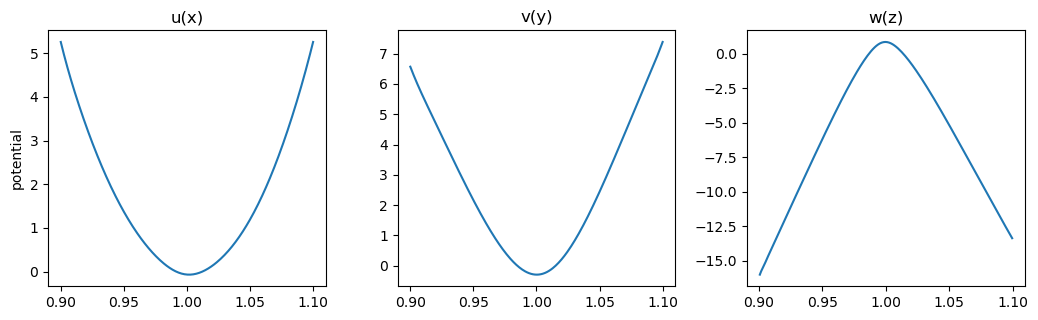

Total mass: 0.9999856573913553
X marginal max abs error: 0.00040746159275784066
Y marginal max abs error: 0.00036516901024796766
-0.06911318963614033 5.257132331360633 -0.2954034862970678 7.385615580515364 -23.575627227546647 0.8562513336073607


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
axes[0].plot(xX, u); axes[0].set_title("u(x)"); axes[0]  # plots the converged u values againt their X-grid points
axes[0].set_ylabel("potential")
axes[1].plot(yY, v); axes[1].set_title("v(y)"); axes[1]  # same idea but for v against the Y-grid


z_display_lo, z_display_hi = 0.9, 1.1   # defines a narrower display window and builds a True/False mask marking which z points fall inside it
mask = (zZ >= z_display_lo) & (zZ <= z_display_hi)
axes[2].plot(zZ[mask], wZ[mask]); axes[2].set_title("w(z)"); axes[2]  #plots only the cropped portion of w, hiding the noise thingsupport edges
plt.tight_layout()
plt.show()

wZ_interp = PchipInterpolator(zZ, wZ, extrapolate=False)   # rebuilds w as a callable function from its final converged values
xy_clipped = np.clip(xovery, zZ.min(), zZ.max())
y_w_kernel = y_mesh * wZ_interp(xy_clipped)   #third ansatz term
joint_density = np.exp(np.clip(u[:,None] + v[None,:] + y_w_kernel, -700, 700)) * Mu_X[:,None] * Mu_Y[None,:]  # Ansatz formula , computed with real numbers now instead of logs

test_X = np.sum(joint_density * y_w[None,:], axis=1)  # re-integrates the joint density over y, should reproduce  mu_X ()
test_Y = np.sum(joint_density * x_w[:,None], axis=0)  # same thing but over x and should reproduce mu_Y

print("Total mass:", np.sum(joint_density * x_w[:,None] * y_w[None,:]))   #multiplies every grid cell of the joint density by both its x weight and y weight, then sums over the entire grid at once, so it collapses both dimensions. This approximates the double integral (ie. total prob mass)
print("X marginal max abs error:", np.max(np.abs(test_X - Mu_X)))   # it finds the single largest gap, anywhere on the grid between what the sinkhorn recoverd and the real target
print("Y marginal max abs error:", np.max(np.abs(test_Y - Mu_Y)))  


print(u.min(), u.max(), v.min(), v.max(), wZ.min(), wZ.max())


Step 5: recover the Z-marginal from the converged potentials (same check as X, Y), then reconstruct implied vol curves from the Sinkhorn joint density and compare to market/SVI (Figure 2 equivalent)

Z marginal max abs error: 1.7442410893409033e-07


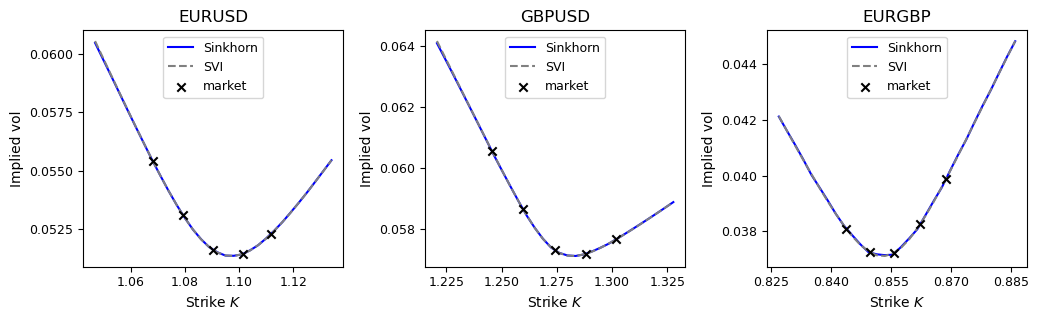

In [17]:
# Recover the Z-marginal from the converged potentials (same idea as test_X, test_Y) 
# This block runs the pipeline backwards: everywhere else we go market vols -> SVI-> density, here we go density-> call price-> implied vol, so the result can be compared with the quotes

from matplotlib.ticker import MaxNLocator

def compute_Z_density(z, u_cur, v_interp, w_val):
    x_over_z = xX / z
    in_support = (x_over_z >= yY.min()) & (x_over_z <= yY.max())
    if not np.any(in_support):
        return 0.0
    x_over_z_safe = np.clip(x_over_z, yY.min(), yY.max())
    v_xz = v_interp(x_over_z_safe)
    mu_bar_xz = np.clip(Mu_X * muY_cont(x_over_z_safe), 1e-300, None)
    A = u_cur + v_xz + np.log(x_w) + np.log(xX**2 / z**3) + np.log(mu_bar_xz)
    A = np.where(in_support, A, -np.inf)
    return np.exp(logsumexp(A + x_over_z_safe * w_val))

test_Z = np.array([compute_Z_density(z, u, v_interp, wZ[i]) for i, z in enumerate(zZ)])
print("Z marginal max abs error:", np.max(np.abs(test_Z - Mu_Z)))

# Reconstruct implied vol curves from the Sinkhorn joint density 

def density_to_impliedvol_curve(nodes_norm, weights_q, density_norm, F0_raw, T, K_targets):
    idx = np.argsort(nodes_norm)  #sort the nodes intp incresaing order
    n_sorted, d_sorted, w_sorted = nodes_norm[idx], density_norm[idx], weights_q[idx] #keep nodes, density and weights aligned under the sort
    ivols = []
    for K_raw in K_targets:  #one implied vol per strike we want to plot
        k_norm = K_raw / F0_raw  #the densities lives in moneyness (s=K/F0), so put the strike in the same units
        payoff = np.maximum(n_sorted - k_norm, 0.0)   #call payoff (x-k)^+ evaluated at all 400 nodes
        call_raw = np.sum(payoff * d_sorted * w_sorted) * F0_raw   #Gauss-Legendre quadrature of payoff x density; the F0 converts moneyness units back to currency
        try:
            iv = bisect(lambda s: bs_call(F0_raw, K_raw, s, T) - call_raw, 1e-4, 2.0)  #find the vol s at which Black-Scholes reproduces the price just computed. This is the definition of implied volatility; bisect searches between 0.01% and 200%.
        except ValueError:
            iv = np.nan  # bisect raises if the endpoints do not bracket a root, i.e. no vol in [1e-4, 2.0] gives that price. Record NaN so the curve has a gap instead of crashing
        ivols.append(iv)
    return np.array(ivols)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))


pairs_plot = [("EURUSD", xX, x_w, test_X), ("GBPUSD", yY, y_w, test_Y), ("EURGBP", zZ, z_w, test_Z)]

for ax, (pair, nodes, weights, density_norm) in zip(axes, pairs_plot):
    F0 = market_data[pair]["F0"]
    K_market = market_data[pair]["K"]
    K_test = np.linspace(K_market.min()*0.98, K_market.max()*1.02, 30)

    recovered_iv = density_to_impliedvol_curve(nodes, weights, density_norm, F0, T, K_test)

    a, b, sig, rho, m = (svi_results[pair]["a"], svi_results[pair]["b"],
                         svi_results[pair]["sig"], svi_results[pair]["rho"], svi_results[pair]["m"])
    svi_iv = Gath_impvol(np.log(K_test/F0), a, b, sig, rho, m, T)

    ax.plot(K_test, recovered_iv, label="Sinkhorn", color="blue")
    ax.plot(K_test, svi_iv, label="SVI", color="grey", linestyle="--")
    ax.scatter(K_market, market_data[pair]["vol"], c="black", label="market", zorder=5, marker="x")
    ax.set_title(pair, fontsize=12)
    ax.set_xlabel("Strike $K$", fontsize=10)
    ax.set_ylabel("Implied vol", fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.legend(fontsize=9, loc="upper center")

plt.tight_layout()
plt.show()

Step 6: correlation between EUR/USD and GBP/USD implied by the converged Sinkhorn joint density 

In [18]:
weights_2d_joint = joint_density * x_w[:, None] * y_w[None, :]   # (probability of each cell), the 2D grid of probability weights, built from the joint density

mean_X = np.sum(x_mesh * weights_2d_joint)   # E[X] under the Sinkhorn joint density
mean_Y = np.sum(y_mesh * weights_2d_joint)   # E[Y]
var_X = np.sum((x_mesh - mean_X)**2 * weights_2d_joint)   # Var[X]
var_Y = np.sum((y_mesh - mean_Y)**2 * weights_2d_joint)   # Var[Y]
cov_XY = np.sum((x_mesh - mean_X) * (y_mesh - mean_Y) * weights_2d_joint)   # Cov[X,Y]

correlation_XY = cov_XY / np.sqrt(var_X * var_Y)

print(f"mean_X = {mean_X:.6f}, mean_Y = {mean_Y:.6f}")
print(f"Sinkhorn-implied correlation between EUR/USD and GBP/USD: {correlation_XY:.4f}")

mean_X = 0.999986, mean_Y = 0.999986
Sinkhorn-implied correlation between EUR/USD and GBP/USD: 0.7676


In [19]:
import itertools   # Margrabe cross-check, following Remark 2.6 of Forde

rs = [(sx**2 + sy**2 - sz**2)/(2*sx*sy)
      for sx, sy, sz in itertools.product(EURUSD_vol, GBPUSD_vol, EURGBP_vol)]

rho_atm = (0.0516**2 + 0.0573**2 - 0.037225**2)/(2*0.0516*0.0573)   # ATM quotes only

print(f"Margrabe range over all 5x5x5 combinations: [{min(rs):.4f}, {max(rs):.4f}]")
print(f"Margrabe at-the-money only:                 {rho_atm:.4f}")
print(f"Sinkhorn-implied correlation:               {correlation_XY:.4f}")

Margrabe range over all 5x5x5 combinations: [0.7355, 0.7974]
Margrabe at-the-money only:                 0.7712
Sinkhorn-implied correlation:               0.7676


In [20]:
# Margrabe cross-check on the Sinkhorn-implied correlation.
# ATM = the quote nearest the forward, which is index 2 for all three pairs (see Table 1).

sX = EURUSD_vol[2]      # 0.0516
sY = GBPUSD_vol[2]      # 0.0573
sZ = EURGBP_vol[2]      # 0.037225

# Margrabe:  sZ^2 = sX^2 + sY^2 - 2*rho*sX*sY   ->   solve for rho
numerator   = sX**2 + sY**2 - sZ**2
denominator = 2 * sX * sY
rho_margrabe = numerator / denominator

print(f"sigma_X = {sX},  sigma_Y = {sY},  sigma_Z = {sZ}")
print(f"numerator   = {sX**2:.8f} + {sY**2:.8f} - {sZ**2:.8f} = {numerator:.8f}")
print(f"denominator = 2 * {sX} * {sY} = {denominator:.8f}")
print(f"rho (Margrabe) = {rho_margrabe:.4f}")
print(f"rho (Sinkhorn) = {correlation_XY:.4f}")
print(f"difference     = {abs(rho_margrabe - correlation_XY):.4f}"
      f"  ({abs(rho_margrabe - correlation_XY)/correlation_XY*100:.2f}%)")

sigma_X = 0.0516,  sigma_Y = 0.0573,  sigma_Z = 0.037225
numerator   = 0.00266256 + 0.00328329 - 0.00138570 = 0.00456015
denominator = 2 * 0.0516 * 0.0573 = 0.00591336
rho (Margrabe) = 0.7712
rho (Sinkhorn) = 0.7676
difference     = 0.0036  (0.47%)


Step 6b: independence-coupling comparison: correlation of Mu_X (x) Mu_Y (product of the two marginals, no Sinkhorn adjustment, no third smile involved).

In [21]:
independence_density = Mu_X[:, None] * Mu_Y[None, :]   # product of the marginals - no Sinkhorn adjustment, no third smile
weights_2d_indep = independence_density * x_w[:, None] * y_w[None, :]

mean_X_indep = np.sum(x_mesh * weights_2d_indep)
mean_Y_indep = np.sum(y_mesh * weights_2d_indep)
var_X_indep = np.sum((x_mesh - mean_X_indep)**2 * weights_2d_indep)
var_Y_indep = np.sum((y_mesh - mean_Y_indep)**2 * weights_2d_indep)
cov_XY_indep = np.sum((x_mesh - mean_X_indep) * (y_mesh - mean_Y_indep) * weights_2d_indep)

correlation_XY_indep = cov_XY_indep / np.sqrt(var_X_indep * var_Y_indep)

print(f"Independence-coupling correlation (Mu_X x Mu_Y, no third smile used): {correlation_XY_indep:.6f}")
print(f"Sinkhorn-implied correlation (uses all three smiles):                 {correlation_XY:.4f}")

Independence-coupling correlation (Mu_X x Mu_Y, no third smile used): 0.000000
Sinkhorn-implied correlation (uses all three smiles):                 0.7676


# PRICING EXOTIC OPTIONS


In [22]:
payoff_basket = np.maximum(0.5*(x_mesh + y_mesh) - 1, 0)
price_basket = np.sum(payoff_basket * joint_density * x_w[:,None] * y_w[None,:])

payoff_quanto = np.maximum(x_mesh/y_mesh - 1, 0)
price_quanto = np.sum(payoff_quanto * joint_density * x_w[:,None] * y_w[None,:])

payoff_bestof = np.maximum(np.maximum(x_mesh, y_mesh) - 1, 0)
price_bestof = np.sum(payoff_bestof * joint_density * x_w[:,None] * y_w[None,:])

payoff_quadratic = (x_mesh - y_mesh)**2
price_quadratic = np.sum(payoff_quadratic * joint_density * x_w[:,None] * y_w[None,:])

option_prices = pd.DataFrame({
    "E((1/2(X+Y)-1)+)": [price_basket], 
    "E((X/Y-1)+)": [price_quanto],
    "E((max(X,Y)-1)+)": [price_bestof],
    "E((X-Y)^2)": [price_quadratic]
})
print(option_prices.round(4))

   E((1/2(X+Y)-1)+)  E((X/Y-1)+)  E((max(X,Y)-1)+)  E((X-Y)^2)
0            0.0059       0.0043            0.0084      0.0001


In [23]:
var_diff = var_X + var_Y - 2*cov_XY
print(f"Var(X-Y)= {var_diff:.8f}")
print(f"price_quadratic= {price_quadratic:.8f}  ")
print(f"sd(X-Y)= {np.sqrt(var_diff):.6f}")
print(f"Var(X-Y) at zero correlation = {var_X + var_Y:.8f}")

Var(X-Y)= 0.00012195
price_quadratic= 0.00012195  
sd(X-Y)= 0.011043
Var(X-Y) at zero correlation = 0.00051665


# DEPENDENCE UNCERTAINTY IN RISK AGGREGATION


Block 1: built the four tail-restricted, negated marginal matrices

In [24]:
alpha = 0.90
N_ra = 1000  # RA discretisation size (independent of Task 2's Gauss-Legendre N=400)

def build_quantile_function(density_func, n_grid=10000):   #this turns  the density function into quantile function 
    lo, hi = density_func.x.min(), density_func.x.max()    
    grid = np.linspace(lo, hi, n_grid)
    density_vals = np.clip(density_func(grid), 0, None)    # evaluates the density at each grip point, clipping away very small floating-points noise
    cdf_vals = np.concatenate(([0], np.cumsum(0.5 * (density_vals[1:] + density_vals[:-1]) * np.diff(grid))))  #builds the CDF by cumulatively integrating the density, strating from 0, (average of each adjacent pair multiplied by the gap between the corresponding grid points)
    cdf_vals = cdf_vals / cdf_vals[-1]                  #rescales so the CDF ends exactly at 1 (small numerical drift o/w)
    return lambda p: np.interp(p, cdf_vals, grid)       #given any probability p, linearly interpolate inside (CDF, grid) table to read off the corresponding x-value (this is what basically a quantile function does)

FX_inv = build_quantile_function(muX_func)   #this is then applied to the EUR/USD and GBP/USD marginal densities
FY_inv = build_quantile_function(muY_func)

# Negated-marginal quantile functions: F_{-X}^{-1}(p) = -F_X^{-1}(1-p)
FX_negated_inv = lambda p: -FX_inv(1 - p)
FY_negated_inv = lambda p: -FY_inv(1 - p)

def worst_case_matrices(FXinv, FYinv, alpha, N):   
    i = np.arange(1, N + 1)
    p_lo = alpha + (1 - alpha) * (i - 1) / N
    p_hi = alpha + (1 - alpha) * i / N
    return np.column_stack([FXinv(p_lo), FYinv(p_lo)]), np.column_stack([FXinv(p_hi), FYinv(p_hi)])  # builds x_alpha and x_bar_alpha (eq 18, EPR13) by stacking X's and Y's quantiles as two columns, one row per tail slice

def best_case_matrices(FXinv, FYinv, alpha, N):
    i = np.arange(1, N + 1)
    p_lo = alpha * (i - 1) / N
    p_hi = alpha * i / N
    return np.column_stack([FXinv(p_lo), FYinv(p_lo)]), np.column_stack([FXinv(p_hi), FYinv(p_hi)])   #(eq 20, EPR13) this feeds the other procedure the one that searches for the largest combined sum 

# Note:  "Z" is just EPR13's own label for their best-case procedure, unrelated to the EUR/GBP cross-rate Z used elsewhere.

worst_case_matrix_lower, worst_case_matrix_upper = worst_case_matrices(FX_negated_inv, FY_negated_inv, alpha, N_ra)   # eq (18) on (-X,-Y) -> feeds smallest_quantile_S
best_case_matrix_lower, best_case_matrix_upper = best_case_matrices(FX_negated_inv, FY_negated_inv, alpha, N_ra)      # eq (20) on (-X,-Y) -> feeds largest_quantile_S

print("worst_case_matrix_lower:", worst_case_matrix_lower.shape, "range:", (worst_case_matrix_lower.min(), worst_case_matrix_lower.max()), "any NaN:", np.any(np.isnan(worst_case_matrix_lower)))
print("worst_case_matrix_upper:", worst_case_matrix_upper.shape, "range:", (worst_case_matrix_upper.min(), worst_case_matrix_upper.max()), "any NaN:", np.any(np.isnan(worst_case_matrix_upper)))
print("best_case_matrix_lower:", best_case_matrix_lower.shape, "range:", (best_case_matrix_lower.min(), best_case_matrix_lower.max()), "any NaN:", np.any(np.isnan(best_case_matrix_lower)))
print("best_case_matrix_upper:", best_case_matrix_upper.shape, "range:", (best_case_matrix_upper.min(), best_case_matrix_upper.max()), "any NaN:", np.any(np.isnan(best_case_matrix_upper)))

worst_case_matrix_lower: (1000, 2) range: (-0.9808195827783737, -0.9289059209425599) any NaN: False
worst_case_matrix_upper: (1000, 2) range: (-0.9808100235876205, -0.5502905448340405) any NaN: False
best_case_matrix_lower: (1000, 2) range: (-1.3757681372099422, -0.9787407749804645) any NaN: False
best_case_matrix_upper: (1000, 2) range: (-1.0547069014868395, -0.9786481646332414) any NaN: False


Block 2: iterative rearrangement (EPR13 steps 3-6): random permutation + reorder-each-column-oppositely-against-the-rest, repeated until the s/t functional converges within epsilon. Applied to all four Block 1 matrices (Xn_alpha, Xn_alpha_bar via s; Zn_alpha, Zn_alpha_bar via t).

In [25]:
def rearrange_column_oppositely(matrix, j):   # EPR13 step 4: reorder column j so it becomes opposite to everything else (this case we only have 2 columns)
    other_sum = matrix.sum(axis=1) - matrix[:, j]   # sum of each row minus column j's own value (for 2 columns, this leaves the other column)
    order_other = np.argsort(other_sum)   # row ranking from the smallest to the largest of the other column
    new_matrix = matrix.copy()
    new_matrix[order_other, j] = np.sort(matrix[:, j])[::-1]  #takes the column j's own values sorted biggest-to-smallest and assigns them to rows in order_other so the row with the smallest "other" value gets the biggest value here and vice versa
    return new_matrix

def s_func(matrix):   #computes every row's total (X+Y), then keeps the smallest one (EPR13's s(x), tracked by the worst-case/eq 18 procedure) 
    return matrix.sum(axis=1).min()

def t_func(matrix):   #same as s_func but now it keeps the largest one (EPR13's t(X), tracked by the best-case/eq 20 procedure)
    return matrix.sum(axis=1).max()

def rearrangement_algorithm(matrix, functional, eps=1e-6, max_iter=20, rng=None):  #EPR13 steps 3-5
    rng = rng or np.random.default_rng()  #use the passed-in random generator, or make a new one if none given
    X = matrix.copy()                     # work on a copy so Block 1's original matrix is never modified
    for j in range(X.shape[1]):           # EPR13 step 3: shuffle each column's own values randomly before starting, gives the search a random starting point (which helps it converge)
        X[:, j] = rng.permutation(X[:, j])
    prev = functional(X)                  # calls whichever function was passed in (s_func or t_func) records the starting value, to compare against after each round
    for it in range(1, max_iter + 1):      
        for j in range(X.shape[1]):
            X = rearrange_column_oppositely(X, j)   # EPR13 step 4: go through every column one at a time, fixing each so it's opposite the rest
        new = functional(X)               # same functional as above (s_func or t_func, whichever this call is using) recomputed after this round's rearranging
        if abs(new - prev) < eps:         # EPR13 step 5: barely changed since last round, converged, stop early and report how many rounds it took
            return X, new, it
        prev = new                        # save this round's value, so next round can compare against it
    return X, prev, max_iter              # only reached if convergence never happened after all max_iter rounds returns the last result we have instead of giving nothing back

eps = 1e-6                               # how small a change in s/t counts as "converged"
rng = np.random.default_rng(42)          # fixed starting point, so re-running the code gives the same random shuffles every time

# worst_case_rearranged_lower/upper  <->  paper's X*, X_bar* (from eq 18's X^alpha, X_bar^alpha)
# best_case_rearranged_lower/upper   <->  paper's Z*, Z_bar* (from eq 20's Z^alpha, Z_bar^alpha)
worst_case_rearranged_lower, worst_case_bound_lower, iterations_worst_lower = rearrangement_algorithm(worst_case_matrix_lower, s_func, eps, rng=rng)   # eq 18-19, s
worst_case_rearranged_upper, worst_case_bound_upper, iterations_worst_upper = rearrangement_algorithm(worst_case_matrix_upper, s_func, eps, rng=rng)   # eq 18-19, s
best_case_rearranged_lower, best_case_bound_lower, iterations_best_lower = rearrangement_algorithm(best_case_matrix_lower, t_func, eps, rng=rng)   # eq 20-21, t
best_case_rearranged_upper, best_case_bound_upper, iterations_best_upper = rearrangement_algorithm(best_case_matrix_upper, t_func, eps, rng=rng)   # eq 20-21, t

print(f"Worst-case (eq 18): worst_case_bound_lower={worst_case_bound_lower:.6f} ({iterations_worst_lower} iters), worst_case_bound_upper={worst_case_bound_upper:.6f} ({iterations_worst_upper} iters)")
print(f"Best-case  (eq 20): best_case_bound_lower={best_case_bound_lower:.6f} ({iterations_best_lower} iters), best_case_bound_upper={best_case_bound_upper:.6f} ({iterations_best_upper} iters)")
print("worst_case_bound_lower <= worst_case_bound_upper:", worst_case_bound_lower <= worst_case_bound_upper)
print("best_case_bound_lower <= best_case_bound_upper:", best_case_bound_lower <= best_case_bound_upper)

Worst-case (eq 18): worst_case_bound_lower=-1.946503 (2 iters), worst_case_bound_upper=-1.946467 (2 iters)
Best-case  (eq 20): best_case_bound_lower=-2.003829 (2 iters), best_case_bound_upper=-2.003754 (2 iters)
worst_case_bound_lower <= worst_case_bound_upper: True
best_case_bound_lower <= best_case_bound_upper: True


Block 3: Block 2 gave bounds on the negated sum $-S$ (since everything ran on $-X, -Y$). Block 3's job is to flip those bounds back into bounds on the real sum $S=X+Y$, using the negation identity from Block 1

In [26]:
smallest_quantile_S = -(worst_case_bound_lower + worst_case_bound_upper) / 2     # we take the average as lower/upper are both for the best single estimate approximations of the same true value (they converge as N grows), so they are averaged and then negate which flips the -S bound back into the smalles /largest S-quantile
largest_quantile_S = -(best_case_bound_lower + best_case_bound_upper) / 2

print(f"smallest_quantile_S = {smallest_quantile_S:.6f}")
print(f"largest_quantile_S  = {largest_quantile_S:.6f}")
print("smallest_quantile_S <= largest_quantile_S:", smallest_quantile_S <= largest_quantile_S)
print(f"Finite-N accuracy gap: worst-case -> {abs(worst_case_bound_upper - worst_case_bound_lower):.2e}, best-case -> {abs(best_case_bound_upper - best_case_bound_lower):.2e}")

smallest_quantile_S = 1.946485
largest_quantile_S  = 2.003792
smallest_quantile_S <= largest_quantile_S: True
Finite-N accuracy gap: worst-case -> 3.56e-05, best-case -> 7.52e-05


Block 4: turns Block 3 quantile bounds into loss numbers, applies the basket payoff to each bound and substracts from the premium. Since the payoff only goes up as S goes up, the  smallest S gives the biggest loss (worst case) and the largest S gives the smallest loss (best case)

In [27]:
def basket_payoff_function(S):
    return np.maximum(0.5 * S - 1, 0)

V0_basket = price_basket  # Sinkhorn-implied basket premium, from Task 3

VaR_worst_basket = V0_basket - basket_payoff_function(smallest_quantile_S)   # smallest q_(1-alpha)(S) -> largest loss
VaR_best_basket  = V0_basket - basket_payoff_function(largest_quantile_S)    # largest  q_(1-alpha)(S) -> smallest loss

print(f"V0 (basket premium): {V0_basket:.6f}")
print(f"VaR_worst (largest possible loss):  {VaR_worst_basket:.6f}")
print(f"VaR_best  (smallest possible loss): {VaR_best_basket:.6f}")
print("VaR_best <= VaR_worst:", VaR_best_basket <= VaR_worst_basket)

V0 (basket premium): 0.005886
VaR_worst (largest possible loss):  0.005886
VaR_best  (smallest possible loss): 0.003990
VaR_best <= VaR_worst: True


Block 5: VaR under the real, calibrated Sinkhorn dependence not the artificail worst/best extremes from Blocks 1-4

In [28]:
S_mesh = x_mesh + y_mesh                                      #every possible combined value of X+Y across the whole grid
weights_2d = joint_density * x_w[:, None] * y_w[None, :]      #probability weight if each (x,y) gridd cell, same weighting as Task 3 own pricing
weights_flat = weights_2d.flatten()                           # collpase the 2D grid into one long list so a 1D CDF can be built
weights_flat = weights_flat / weights_flat.sum()              #renormalise       

order = np.argsort(S_mesh.flatten())                          #ranks every grid point by its S value smallest to largest
S_sorted = S_mesh.flatten()[order]                            #the S value, now actually rearranged into sorted order
cdf_S = np.cumsum(weights_flat[order])                        #matching weights rearranged the same way, then running totalled (this is the empirical CDF of S under the Sinkhorn joint)

q_S_sinkhorn = np.interp(1 - alpha, cdf_S, S_sorted)          #same V0 payoff conversion as Block 4 applied to the real Sinkhorn quantile instead of a dependence uncertainty bound
VaR_sinkhorn_basket = V0_basket - basket_payoff_function(q_S_sinkhorn)

print(f"Sinkhorn-implied q_(1-alpha)(S): {q_S_sinkhorn:.6f}")             # qunatile just compuetd
print(f"Sinkhorn-implied VaR (basket loss): {VaR_sinkhorn_basket:.6f}")   #the real loss number
print()
results_basket = pd.DataFrame({
    "VaR_best (dep. uncertainty)": [VaR_best_basket],
    "VaR_Sinkhorn": [VaR_sinkhorn_basket],
    "VaR_worst (dep. uncertainty)": [VaR_worst_basket],
})
print(results_basket.round(6))
print("VaR_best <= VaR_Sinkhorn <= VaR_worst:", VaR_best_basket <= VaR_sinkhorn_basket <= VaR_worst_basket)   #sanity check

Sinkhorn-implied q_(1-alpha)(S): 1.961857
Sinkhorn-implied VaR (basket loss): 0.005886

   VaR_best (dep. uncertainty)  VaR_Sinkhorn  VaR_worst (dep. uncertainty)
0                      0.00399      0.005886                      0.005886
VaR_best <= VaR_Sinkhorn <= VaR_worst: True


Diagnostic (inspection only, not part of Blocks 1-5) checks whether the VaR collapse is forced by construction: what fraction of the Sinkhorn-implied distribution of S=X+Y is actually above the strike (2), where the strike sits relative to the median of S, and the crossover confidence level at which q_(1-alpha)(S) would equal the strike.

In [29]:
strike_S = 2.0  # basket payoff g(S)=max(0.5S-1,0) is positive only for S > strike_S

F_S_at_strike = np.interp(strike_S, S_sorted, cdf_S)   # F_S(2) under the Sinkhorn joint
P_S_above_strike = 1 - F_S_at_strike                   # P(S > 2): crossover alpha* such that q_(1-alpha*)(S) = 2  (it's the confidence level at which VaR would just barely start being non-zero)

median_S = np.interp(0.5, cdf_S, S_sorted)             #50 th perecentile of S, same backward-CDF trick as Block 5 q_S_sinkhorn but at prob 0.5
mean_S = np.average(S_mesh.flatten(), weights=weights_flat)  #E[] under the Sinkhorn joint, a plain weighted average, no sorting needed

print(f"F_S(2) under Sinkhorn joint: {F_S_at_strike:.6f}")    #how much probability mass sits at or bellow the strike
print(f"P(S > 2) = crossover alpha*: {P_S_above_strike:.6f}") #how much probability mass is actually in-the-money
print(f"chosen alpha = {alpha}  ->  looking at the {1-alpha:.4f} lower tail") #how close S's sits to the strike
print(f"median(S) = {median_S:.6f}, mean(S) = {mean_S:.6f}, strike = {strike_S}") #how close S's centre sits to the strike
print(f"q_(1-alpha)(S) < strike:", q_S_sinkhorn < strike_S)   # True means the quantile is in the zero-payoff region confirming why VaR collapses to V0

F_S(2) under Sinkhorn joint: 0.499555
P(S > 2) = crossover alpha*: 0.500445
chosen alpha = 0.9  ->  looking at the 0.1000 lower tail
median(S) = 2.000779, mean(S) = 2.000000, strike = 2.0
q_(1-alpha)(S) < strike: True


In [30]:
lo, hi = smallest_quantile_S, largest_quantile_S
width = hi - lo
gap   = mean_S - q_S_sinkhorn
print(f"band width           = {width:.6f}")
print(f"as % of midpoint     = {100*width/((lo+hi)/2):.3f}%")
print(f"mean(S) - q_sinkhorn = {gap:.6f}")
print(f"width / that gap     = {width/gap:.3f}")
print(f"std(S)               = {np.sqrt(var_X + var_Y + 2*cov_XY):.6f}")

band width           = 0.057307
as % of midpoint     = 2.901%
mean(S) - q_sinkhorn = 0.038143
width / that gap     = 1.502
std(S)               = 0.030189


Plot 1: VaR bounds across a range of confidence levels (alpha). Repeats Blocks 1-4's logic for each alpha in the list below, WITHOUT disturbing the `alpha` set at the top of Block 1 (that value is left untouched for the rest of the notebook). Numbers are freshly computed here, not hardcoded from earlier manual runs.

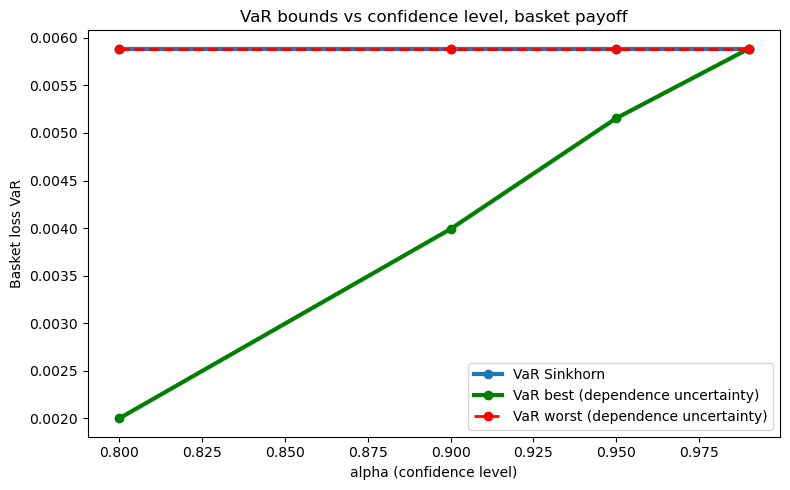

   alpha  VaR_best  VaR_Sinkhorn  VaR_worst
0   0.80  0.001999      0.005886   0.005886
1   0.90  0.003990      0.005886   0.005886
2   0.95  0.005155      0.005886   0.005886
3   0.99  0.005886      0.005886   0.005886


In [31]:
#Repeats Blocks 1-4's logic for a single alpha, reusing the same exact functions, same steps run again for a different alpha. Returns (VaR_worst, VaR_best, VaR_sinkhorn)

def compute_basket_var_bounds(alpha_value):
    worst_lower, worst_upper = worst_case_matrices(FX_negated_inv, FY_negated_inv, alpha_value, N_ra)
    best_lower, best_upper = best_case_matrices(FX_negated_inv, FY_negated_inv, alpha_value, N_ra)

    rng_sweep = np.random.default_rng(42)   # same seed each time, for comparability across alpha
    matrix1, worst_bound_lower, iters1 = rearrangement_algorithm(worst_lower, s_func, eps, rng=rng_sweep)
    matrix2, worst_bound_upper, iters2 = rearrangement_algorithm(worst_upper, s_func, eps, rng=rng_sweep)
    matrix3, best_bound_lower, iters3 = rearrangement_algorithm(best_lower, t_func, eps, rng=rng_sweep)
    matrix4, best_bound_upper, iters4 = rearrangement_algorithm(best_upper, t_func, eps, rng=rng_sweep)

    smallest_S = -(worst_bound_lower + worst_bound_upper) / 2   # same negation identity as Block 3
    largest_S = -(best_bound_lower + best_bound_upper) / 2

    VaR_worst = V0_basket - basket_payoff_function(smallest_S)
    VaR_best = V0_basket - basket_payoff_function(largest_S)

    quantile_sinkhorn = np.interp(1 - alpha_value, cdf_S, S_sorted)   # reuse the Sinkhorn joint's own CDF from Block 5
    VaR_sinkhorn = V0_basket - basket_payoff_function(quantile_sinkhorn)

    return VaR_worst, VaR_best, VaR_sinkhorn


alpha_values = [0.80, 0.90, 0.95, 0.99]  # ascending, so the plot reads left-to-right as confidence increases
VaR_worst_list = []
VaR_best_list = []
VaR_sinkhorn_list = []

for alpha_test in alpha_values:
    VaR_worst_this_alpha, VaR_best_this_alpha, VaR_sinkhorn_this_alpha = compute_basket_var_bounds(alpha_test)
    VaR_worst_list.append(VaR_worst_this_alpha)
    VaR_best_list.append(VaR_best_this_alpha)
    VaR_sinkhorn_list.append(VaR_sinkhorn_this_alpha)

plt.figure(figsize=(8, 5))
# VaR_Sinkhorn (solid) plotted FIRST, VaR_worst (dashed) plotted LAST so its dashes
# actually show up on top instead of being covered by the solid line underneath.
plt.plot(alpha_values, VaR_sinkhorn_list, marker='o', linewidth=3, label='VaR Sinkhorn')
plt.plot(alpha_values, VaR_best_list, marker='o', linewidth=3, color="green", label='VaR best (dependence uncertainty)')
plt.plot(alpha_values, VaR_worst_list, marker='o', linestyle='--', linewidth=2, color='red', label='VaR worst (dependence uncertainty)')
plt.xlabel('alpha (confidence level)')
plt.ylabel('Basket loss VaR')
plt.title('VaR bounds vs confidence level, basket payoff')
plt.legend()
plt.tight_layout()
plt.show()

results_table = pd.DataFrame({
    "alpha": alpha_values,
    "VaR_best": VaR_best_list,
    "VaR_Sinkhorn": VaR_sinkhorn_list,
    "VaR_worst": VaR_worst_list,
})
print(results_table.round(6))


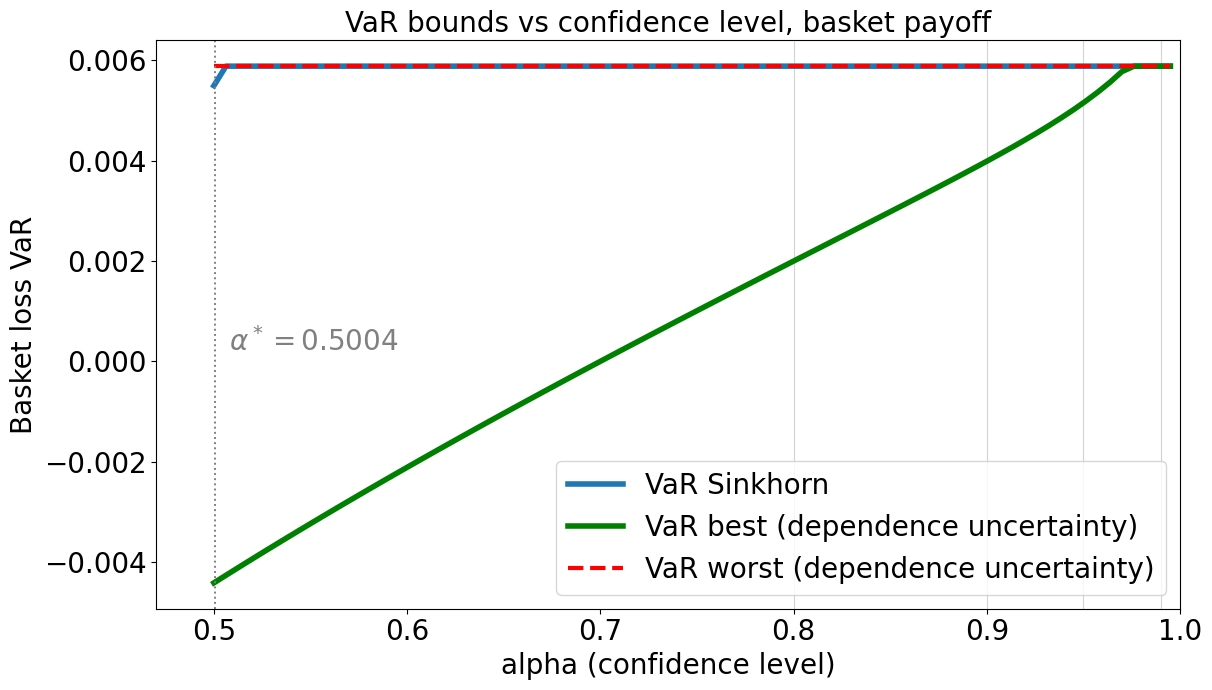

In [32]:
alpha_grid = np.linspace(0.50, 0.995, 80)

worst_list, best_list, sink_list = [], [], []
for a in alpha_grid:
    w, b, s = compute_basket_var_bounds(a)
    worst_list.append(w); best_list.append(b); sink_list.append(s)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(alpha_grid, sink_list,  linewidth=4, label='VaR Sinkhorn')
ax.plot(alpha_grid, best_list,  linewidth=4, color='green',
        label='VaR best (dependence uncertainty)')
ax.plot(alpha_grid, worst_list, linewidth=3, color='red', linestyle='--',
        label='VaR worst (dependence uncertainty)')

ax.axvline(P_S_above_strike, color='grey', linestyle=':', linewidth=1.4)
ax.annotate(r'$\alpha^*=%.4f$' % P_S_above_strike,
            xy=(P_S_above_strike, 0.0002), xytext=(10, 0),
            textcoords='offset points', fontsize=20, color='grey')

for a in [0.80, 0.90, 0.95, 0.99]:
    ax.axvline(a, color='lightgrey', linewidth=0.8, zorder=0)

ax.set_xlabel('alpha (confidence level)', fontsize=20)
ax.set_ylabel('Basket loss VaR', fontsize=20)
ax.set_title('VaR bounds vs confidence level, basket payoff', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20)

plt.tight_layout()
plt.xlim(0.47, 1.0)
plt.show()

In [33]:
for a in np.linspace(0.88, 0.92, 21):
    q = np.interp(1 - a, cdf_S, S_sorted)
    print(f"alpha={a:.4f}  q={q:.6f}")

alpha=0.8800  q=1.965659
alpha=0.8820  q=1.964963
alpha=0.8840  q=1.964894
alpha=0.8860  q=1.964280
alpha=0.8880  q=1.964134
alpha=0.8900  q=1.964109
alpha=0.8920  q=1.963369
alpha=0.8940  q=1.963342
alpha=0.8960  q=1.962617
alpha=0.8980  q=1.962572
alpha=0.9000  q=1.961857
alpha=0.9020  q=1.961801
alpha=0.9040  q=1.961081
alpha=0.9060  q=1.961032
alpha=0.9080  q=1.960305
alpha=0.9100  q=1.960262
alpha=0.9120  q=1.959528
alpha=0.9140  q=1.959490
alpha=0.9160  q=1.958745
alpha=0.9180  q=1.958128
alpha=0.9200  q=1.957966
